# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks


    
|    Group   |           1          |
|------------|----------------------|
| Junhan Chong  |        6153283       |
| Jack Bergmann  |        6200850       |
| Madhav Tiwari  |        6141870       |
| Ben Chen  |        6543405       |

</div>

#### Imports

In [36]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import sklearn.metrics as met

#### Loading the data

In [16]:
features = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")

np.random.seed(14)

N = features.shape[0]
perm = np.random.permutation(N)

features = features[perm]
targets = targets[perm]

train_ratio = 0.7
val_ratio = 0.15

train_end = int(train_ratio * N)
val_end = int((train_ratio + val_ratio) * N)

# Training set
train_x = features[:train_end]
train_y = targets[:train_end]

# Validation set
val_x = features[train_end:val_end]
val_y = targets[train_end:val_end]

# Test set
test_x = features[val_end:]
test_y = targets[val_end:]

print(train_x.shape)

(5497, 10)


## 1 Questions
### 1.2 Architecture
#### Question 1:

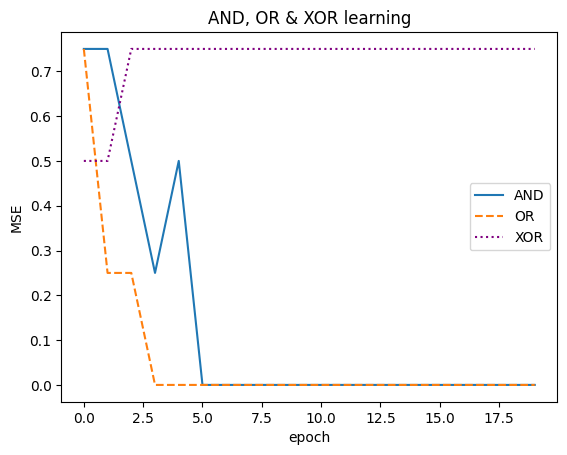

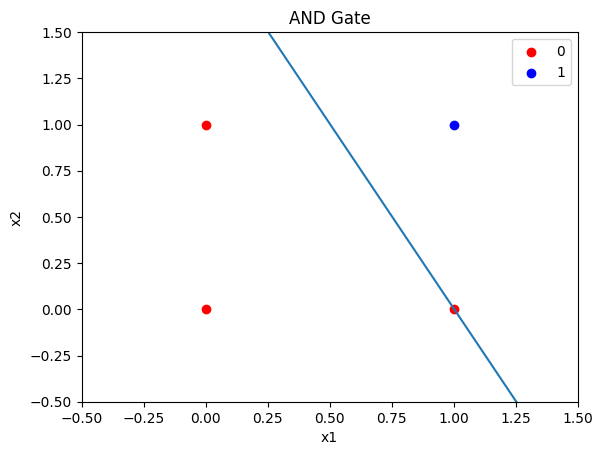

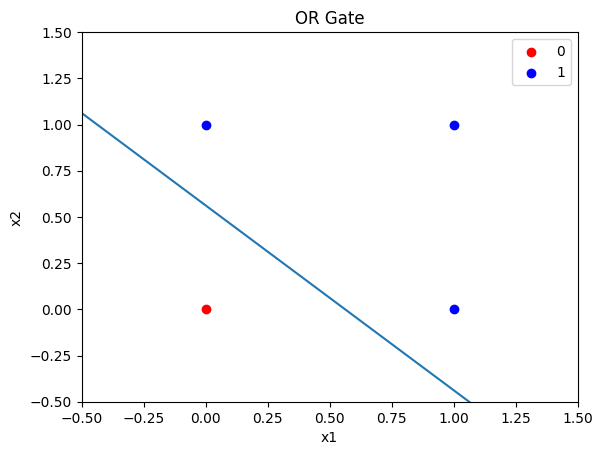

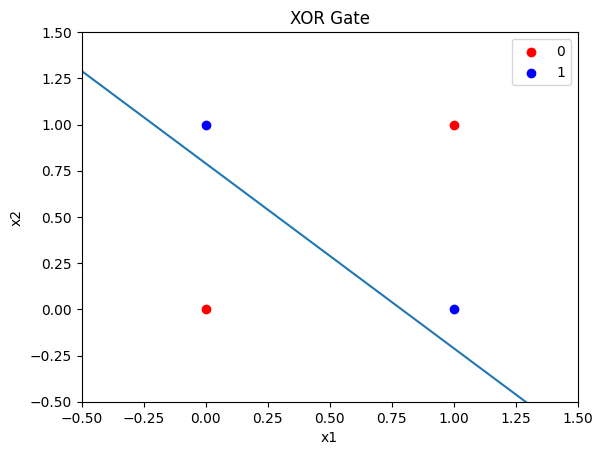

In [17]:
class Perceptron:
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = np.zeros(num_features)
        self.bias = np.random.randn()
        self.a = 0.1
    
    # Step activation
    def step(self, x):
        return np.where(x @ self.weights + self.bias >= 0, 1, 0)
    
    # Perceptron learning rule
    def train(self, x_train, y_train, epochs):
        errors = np.zeros(epochs)
        for i in range(epochs):
            error = np.mean(np.pow(self.step(x_train) - y_train, 2))
            errors[i] = error
            for xi, yi in zip(x_train, y_train):
                pred = self.step(xi)
                if pred != yi:
                    # Update weights and bias only when misclassified
                    error = yi - pred
                    self.weights += self.a * error * xi
                    self.bias += self.a * error
        return errors
    
# plotting functions

def plot_gate(X, y, weights, bias, title):
    plt.figure()
    
    class0 = X[y == 0]
    class1 = X[y == 1]
    
    plt.scatter(class0[:,0], class0[:,1], c = 'r', label = "0")
    plt.scatter(class1[:,0], class1[:,1], c = 'b', label = "1")
    plt.legend()
    
    if weights[1] != 0:
        x_vals = np.linspace(-0.5, 1.5, 100)
        y_vals = -(weights[0] * x_vals + bias) / weights[1]
        plt.plot(x_vals, y_vals)
    
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()



train_x_perp = np.array([[0,0], [0,1], [1,0], [1,1]])

# AND
and_perceptron = Perceptron(2)
y_and = np.array([0, 0, 0, 1])
and_errors = and_perceptron.train(train_x_perp, y_and, 20)



# OR
or_perceptron = Perceptron(2)
y_or = np.array([0, 1, 1, 1])
or_errors = or_perceptron.train(train_x_perp, y_or, 20)



# XOR
xor_perceptron = Perceptron(2)
y_xor = np.array([0, 1, 1, 0])
xor_errors = xor_perceptron.train(train_x_perp, y_xor, 20)

# Plotting

# this shows the loss over epochs as the model learns the weights
plt.title("AND, OR & XOR learning")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.plot(and_errors, label = "AND")
plt.plot(or_errors, label = "OR", linestyle="--")
plt.plot(xor_errors, label = "XOR", linestyle=":", c = "purple")
plt.legend()
plt.show()

plot_gate(train_x_perp, y_and, and_perceptron.weights, and_perceptron.bias, "AND Gate")
plot_gate(train_x_perp, y_or, or_perceptron.weights, or_perceptron.bias, "OR Gate")
plot_gate(train_x_perp, y_xor, xor_perceptron.weights, xor_perceptron.bias, "XOR Gate")


<div>

The perceptron for AND and OR is successfully trained to be able to output the correct values. This is possible because the positive and negative classes are linearly separable. Hence, the error reaches 0 after training.

The regression lines for AND and OR perceptrons doesn't separate the classes with equal amount of padding, which makes sense because once the line separates the classes so that the error is 0, no more updates occur in any of the weights nor the bias.

In contrast, for XOR learning, the error does not reach 0 because the two classes are not linearly separable.


</div>

#### Question 2

<div>

There should be 10 input neurons to take values from the 10 features.

</div>

#### Question 3

<div>

7 output neurons to classify the samples into the 7 possible classes (softmax or argmax)

</div>

#### Question 4

<div>

We think that one hidden layer will suffice to start with. With 6 hidden layers, data is linearly separable so it's illogical. Although two hidden layers also seem to be appropriate, with 10 features, it is faster and more efficient to start with one and gauge t20 network's performance to decide if it should be increased to two.

As for t20 number of neurons per layer, t20re are certain base 20uristics typically followed. One is t20 geometric mean rule, which balances t20 input and output size by taking: sqrt(input_size x output_size). T20 ot20r common 20uristics is t20 2/3 rule, w20re you take 2/3 * (input_size + output_size), which is used usually for regression and/or small datasets. T20 values we obtain from t20se 20uristics for our specific dataset are 8 and 11, respectively. For t20 same reason as above, we pick 8 to start small and scale accordingly.

</div>

#### Question 5

<div>

T20 choice of activation function depends on t20 depth of t20 neural network, and type of predictions (regression/classification). In genereal, sigmoid function would not be used in t20 hidden layers, but in our case, since t20 network won't be too deep, t20 vanishing gradient problem vanis20s (hahaha). And since t20 sigmoid function is differentiable, we can use t20 sigmoid function to simplify computation.

</div>

#### Question 6

<div>

![ANN Diagram](../data/ann_diagram.png)

</div>

### 1.3 Training

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its output with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [5]:
class Linear:
    def __init__(self, in_features, out_features, init_method):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
            init_methods:
                0 - zero initialisation
                1 - normal distribution initialisation (1, 0)
                2 - uniform distribution [0, 1]
                3 - Xavier initialisation (uniform)
                4 - He initialisation (uniform)
        """
        match init_method:
            case 0:
                self.weight = np.zeros((out_features, in_features))
                self.bias = np.zeros(out_features)
            case 1:
                self.weight = np.random.randn(out_features, in_features)
                self.bias = np.random.randn(out_features)
            case 2:
                self.weight = np.random.rand(out_features, in_features)
                self.bias = np.random.rand(out_features)
            case 3:
                degree = in_features + out_features
                limit = math.sqrt(3.0 / degree)
                self.weight = np.random.uniform(-limit, limit, size=(out_features, in_features))
                self.bias = np.random.uniform(-limit, limit, size=(out_features))
            case 4:
                lower = - math.sqrt(6/in_features)
                upper = math.sqrt(6/out_features)
                self.weight = np.random.uniform(lower, upper, size=(out_features, in_features))
                self.bias = np.zeros(out_features)
        

        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None
        self.v_w = np.zeros_like(self.weight)
        self.v_b = np.zeros_like(self.bias)

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns: 
            y: output of a linear layer. 
        """

        
        self.cache = x
        # what is the shape of x? It depends on what a 'linear' is. Is it a single layer with all the neurons in it? Or just a single neuron?
        # assuming it's a whole layer, x would be of shape (N, in_features). self.weight: (out_features, in_features)
        return x @ self.weight.T + self.bias
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        if self.weight_grad is not None:
            self.v_w = self.weight_grad
            self.v_b = self.bias_grad

        
        self.weight_grad = dupstream.T @ self.cache # dupstream: (N, out_features), self.cache: (N, in_features), weight_grad: (out_features, in_features)
        self.bias_grad = np.sum(dupstream, axis=0)
        return dupstream @ self.weight # dupstream: (N, out_features), self.weight: (out_features, in_features), dx: (N, in_features)
    # dx is the effect of changing the input to the loss. Since there are N number of x samples, all with in_features features, the dimension makes sense

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [6]:
class Activation:
    def __init__(self):
        self.cache = None
    
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """

        self.cache = 1 / (1 + np.exp(-x))
        return self.cache
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        
        # given the upstream gradient, calculate how much the change in z(x) affects the loss (dL/dZ) = dupstream * dy / dZ, y = sigmoid(x)
        # significance of upstream gradient? What are its dimensions? x is (N, in_features), dupstream is then (N, in_features) as well?
        return dupstream * (self.cache * (1 - self.cache))

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [7]:
class Network:
    def __init__(self, layer_dimensions, init_method):
        # layer_dimensions is a list containing number of neurons per layer. eg. [10, 8, 7] would be input layer with 10 neurons, hidden layer with 8, then output layer with 7
        self.layers = []
        for i in range(len(layer_dimensions) - 1):
            l = Linear(
                layer_dimensions[i],
                layer_dimensions[i+1],
                init_method
            )
            self.layers.append(l)

            if i < len(layer_dimensions) - 2:
                self.layers.append(Activation())

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        # what is the dimension of layers?? I think it will be (no_layers,)
        for l in self.layers:
            x = l.forward(x)
        return x
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        for l in reversed(self.layers):
            dupstream = l.backward(dupstream)
        return dupstream
    
    def optimizer_step(self, lr, beta):
        """ Calculate momentum
            Update the weight and bias parameters of each layer using momentum

        Args:
            lr: learning rate.
        """
        
        for l in self.layers:
            if isinstance(l, Linear):
                l.v_w = beta * l.v_w + (1 - beta) * l.weight_grad
                l.v_b = beta * l.v_b + (1 - beta) * l.bias_grad
                l.weight -= lr * l.v_w
                l.bias -= lr * l.v_b

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [8]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """
    # assuming that we use softmax, we will have the y_pred (N, 7) to turn into probabilities with same size
    # since y_true is going to be just a single value, we can use the value as index to find the corresponding probability and use cross entropy loss, which is the sum of p_i(true_class)log(p_i(probability)) over all classes
    N = y_true.shape[0]

    y_exp = np.exp(y_pred - np.max(y_pred, axis = 1, keepdims = True))
    y_probs = y_exp / np.sum(y_exp, axis = 1, keepdims = True) # collapse the columns

    pred_correct_prob = y_probs[np.arange(N), y_true.astype(int) - 1]
    # must add a tiny value to the probability in the case that it's 0, as the log of 0 is negative infinity.
    eps = 1e-10
    loss = -np.mean((np.log(pred_correct_prob + eps)))
    # Create a matrix with same shape as y_pred, but turned to 0s and 1s according to predicted probabilities.
    one_hot = np.zeros_like(y_probs)
    one_hot[np.arange(N), y_true.astype(int) - 1] = 1

    grad = (y_probs - one_hot) / N
    
    return (loss, grad)

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [9]:
def train(net, inputs, labels, criterion, lr, momentum_r):
    """Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """

    preds = net.forward(inputs)
    loss_grad = criterion(labels, preds)
    net.backward(loss_grad[1])
    net.optimizer_step(lr, momentum_r)
    pred_classes = np.argmax(preds, axis=1) + 1
    
    return (loss_grad[0], np.mean(pred_classes == labels))

#### Question 7

<div>

There should be three divisions of data for three different roles. They are training data, validating data and test data.
<br> These data separations should be such that the three are not correlated (at the very least, not linearly correlated).

Secondly, they should be partitioned into an appropriate ratios. Since the training is important for the accuracy of the model, the largest partition should be assigned to the training segment.
<br> As for validation and testing, we want to ensure that neither of them are too small; If the validation set is too small, we may have an under-optimised hyper-parameters. <br> If the test set is too small, we may get an inaccurate representation of the model's accuracy.

In order to ensure independence between the sets (no correlation), we should ensure that the dataset is not ordered by a certain feature (or a combination of features).
<br> If needed, we can visually verify that the split data is not correlated through a heatmap. If the data has certain correlations between features, a heatmap would show distinguishable shapes such as a linear line or a circle etc...
<br> We can also pick samples from a random distribution to further ensure randomness.

Finally, I would divide the data into a 70:15:15 ratio which is the standard practice for a small-medium dataset.
<br> To make the splits reproducible, we can also set a fixed random seed when randomly sampling data for each set.



</div>

#### Question 8

<div>

We can evaluate our model with the test set. After training with the training set, and tuning the hyperparameters such as number of layers and number of neurons per layer etc..., we can put the test dataset into the model and find the accuracy. Furthermore, we can repeat this with multiple separation of the dataset and get an average of the accuracy.

The accuracy is a good measure for the performance of the model as the dataset has roughly balanced distribution of the classes and therefore the accuracy will be unbiased for all the classes' accuracy.

We can evaluate our model with the cross entropy metric as we use a softmax probability activation for the final prediction. In this case, we can put the test set into the model and use the predicted probability of the true class to build up our metric. This is useful as we can see if the model has high confidence in its predictions or not.

<b style="background-color:#010101"> Choose between accuracy and cross entropy </b>

</div>

#### Question 9

<div>
We can train our model with our intial hyperparameters (one layer, eight neurons per layer, 0.01 learning rate etc...). T20se are chosen with the reasons stated from the questions above (Q4-5), <br> as well as the standard practice for other hyperparameters. 

We can end the training of our model when the chosen performance metric does not improve with tthe20 validation set. We can keep on tuning the weights and biases within the model while the performance on the validation set continues to improve. Using the validation set is useful to prevent overfitting and ensure that generalisation is not lost.
</div>

#### Question 10

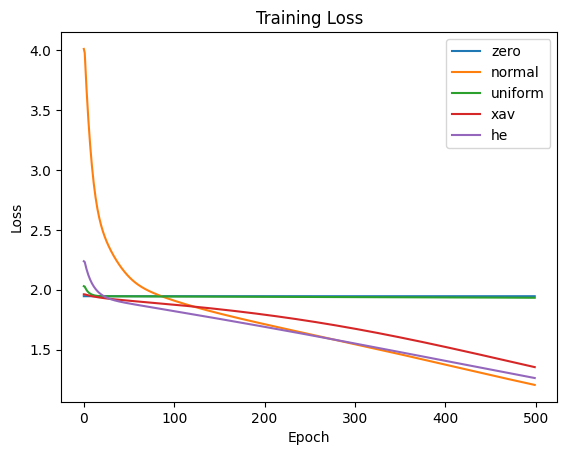

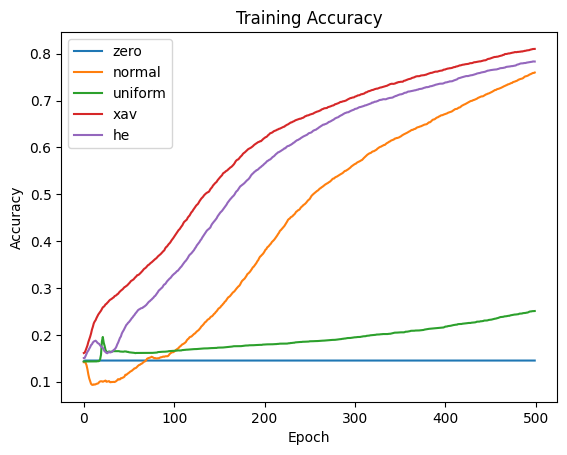

In [10]:
net_zero = Network([10, 8, 7], 0)
net_normal = Network([10, 8, 7], 1)
net_uniform = Network([10, 8, 7], 2)
net_xav = Network([10, 8, 7], 3)
net_he = Network([10, 8, 7], 4)

losses_zero = []
accuracies_zero = []

losses_normal = []
accuracies_normal = []

losses_uniform = []
accuracies_uniform = []

losses_xav = []
accuracies_xav = []

losses_he = []
accuracies_he = []


for i in range(500):
    epoch_loss_zero, epoch_accuracy_zero = train(net_zero, train_x, train_y, Loss, 0.1, 0.8)
    epoch_loss_normal, epoch_accuracy_normal = train(net_normal, train_x, train_y, Loss, 0.1, 0.8)
    epoch_loss_uniform, epoch_accuracy_uniform = train(net_uniform, train_x, train_y, Loss, 0.1, 0.8)
    epoch_loss_xav, epoch_accuracy_xav = train(net_xav, train_x, train_y, Loss, 0.1, 0.8)
    epoch_loss_he, epoch_accuracy_he = train(net_he, train_x, train_y, Loss, 0.1, 0.8)
    
    losses_zero.append(np.mean(epoch_loss_zero))
    accuracies_zero.append(np.mean(epoch_accuracy_zero))

    losses_normal.append(np.mean(epoch_loss_normal))
    accuracies_normal.append(np.mean(epoch_accuracy_normal))

    losses_uniform.append(np.mean(epoch_loss_uniform))
    accuracies_uniform.append(np.mean(epoch_accuracy_uniform))

    losses_xav.append(np.mean(epoch_loss_xav))
    accuracies_xav.append(np.mean(epoch_accuracy_xav))

    losses_he.append(np.mean(epoch_loss_he))
    accuracies_he.append(np.mean(epoch_accuracy_he))



# loss
plt.figure()
plt.plot(losses_zero, label = 'zero')
plt.plot(losses_normal, label = 'normal')
plt.plot(losses_uniform, label = 'uniform')
plt.plot(losses_xav, label = 'xav')
plt.plot(losses_he, label = 'he')
plt.legend()
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# accuracy
plt.figure()
plt.plot(accuracies_zero, label = 'zero')
plt.plot(accuracies_normal, label = 'normal')
plt.plot(accuracies_uniform, label = 'uniform')
plt.plot(accuracies_xav, label = 'xav')
plt.plot(accuracies_he, label = 'he')
plt.legend()
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


<div>

Every initialisation had an increase in accuracy over epochs except the zero-initialisation, with Xavier/He initialisation working most optimally. The zero-initialisation did not improve in performance due to the neurons in every layer collapsing into one. <br> This happens because very neuron has the exact same weights and biases, essentially producing the same output. Therefore, this model can work only as well as a corresponding model with just one neuron in each layer.
Xavier and He initialisation reached the highest accuracy and at the steepest gradient. This is because while the normal initialisation doesn't take the in and out degree of the nodes, which can explode/vanish the gradients, He and Xavier do and therefor the learning is stable.

</div>

### 1.4 Optimization

#### Question 11

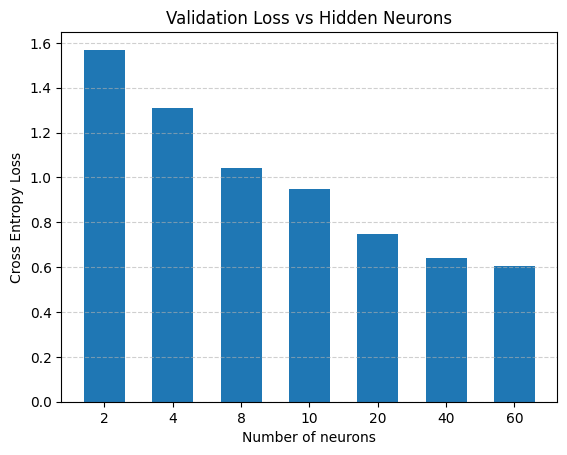

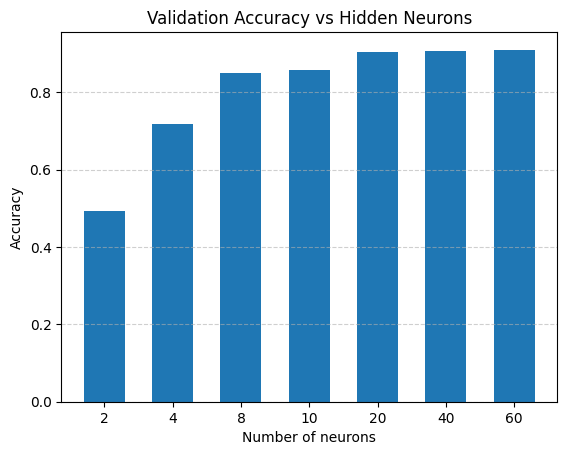

In [11]:
def evaluate(net, inputs, labels, criterion):
    preds = net.forward(inputs)
    loss, _ = criterion(labels, preds)
    pred_classes = np.argmax(preds, axis=1) + 1
    acc = np.mean(pred_classes == labels)
    return loss, acc

def run_experiment(hidden_size):
    net = Network([10, hidden_size, 7], 3)

    for _ in range(800):
        train(net, train_x, train_y, Loss, 0.1, 0.8)

    return evaluate(net, val_x, val_y, Loss)

sizes = [2, 4, 8, 10, 20, 40, 60]
results_loss = {h: [] for h in sizes}
results_acc  = {h: [] for h in sizes}

for _ in range(10):
    for s in sizes:
        loss,acc = run_experiment(s)
        results_loss[s].append(loss)
        results_acc[s].append(acc)
    
avg_losses = [np.mean(results_loss[h]) for h in sizes]
avg_accs   = [np.mean(results_acc[h])  for h in sizes]



x = np.arange(len(sizes))

plt.figure()
plt.bar(x, avg_losses, width=0.6)
plt.xticks(x, sizes)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.title("Validation Loss vs Hidden Neurons")
plt.xlabel("Number of neurons")
plt.ylabel("Cross Entropy Loss")

plt.show()


plt.figure()
plt.bar(x, avg_accs, width=0.6)
plt.xticks(x, sizes)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.title("Validation Accuracy vs Hidden Neurons")
plt.xlabel("Number of neurons")
plt.ylabel("Accuracy")

plt.show()

In [12]:
print(avg_losses)
print(avg_accs)

[np.float64(1.5691112948749975), np.float64(1.3073194084450583), np.float64(1.0412931305933546), np.float64(0.949745476281643), np.float64(0.7492093948364911), np.float64(0.6426091022393178), np.float64(0.6065391879110267)]
[np.float64(0.4926994906621392), np.float64(0.7185059422750424), np.float64(0.849320882852292), np.float64(0.8587436332767403), np.float64(0.9033106960950764), np.float64(0.9075551782682514), np.float64(0.910101867572156)]


<div>

With one single layer, there is a plato in the accuracy after 20 neurons. With a layer of 20 neurons, it reaches 90% accuracy with little gain when doubling. The initial increase in accuracy comes from the layer's increased ability to capture the complexity of the dataset. However, since our data only contains 10 features with 7 output classes, the plato is seen quite quickly as the complexity of the dataset itself is not too high.

</div>

#### Question 12

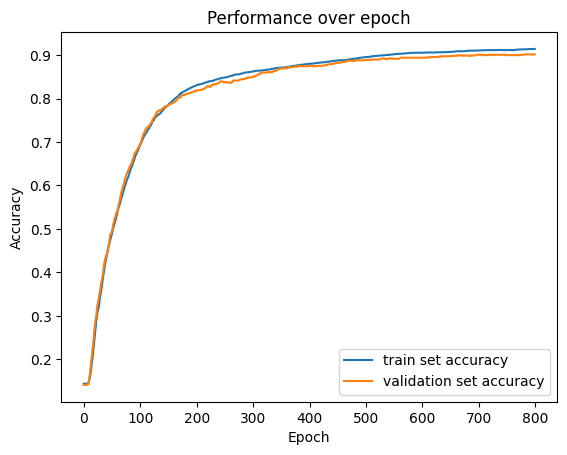

In [13]:
hidden_size = 20
net = Network([10, hidden_size, 7], 3)

results_train_acc = []
results_val_acc = []

for _ in range(800):
    train_loss, train_acc = train(net, train_x, train_y, Loss, 0.1, 0.8)
    val_loss, val_acc = evaluate(net, val_x, val_y, Loss)
    
    results_train_acc.append(train_acc)
    results_val_acc.append(val_acc)


# accuracy
plt.figure()
plt.plot(results_train_acc, label = 'train set accuracy')
plt.plot(results_val_acc, label = 'validation set accuracy')
plt.legend()
plt.title("Performance over epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


<div>

We chose 20 hidden neurones as thats where out plot pleateaued for question 11. Using a lower number would have led to much lower accuracy. Using a higher number would have required greater computation time in exchange for not a lot of performance boost. Our plot for this question shows that the training accuracy increases till around 300 epochs when it starts to plateau out while increasing at a decreasing rate.

</div>

### 1.5 Evaluation

#### Question 13

[np.float64(0.15606446140797287), np.float64(0.15860899067005937), np.float64(0.16793893129770993), np.float64(0.183206106870229), np.float64(0.20610687022900764), np.float64(0.22646310432569974), np.float64(0.2408821034775233), np.float64(0.24851569126378287), np.float64(0.2586938083121289), np.float64(0.26463104325699743), np.float64(0.2680237489397795), np.float64(0.2731128074639525), np.float64(0.2748091603053435), np.float64(0.2765055131467345), np.float64(0.2782018659881255), np.float64(0.27905004240882103), np.float64(0.27989821882951654), np.float64(0.28329092451229854), np.float64(0.28413910093299405), np.float64(0.2824427480916031), np.float64(0.28498727735368956), np.float64(0.2866836301950806), np.float64(0.2883799830364716), np.float64(0.2909245122985581), np.float64(0.2951653944020356), np.float64(0.2968617472434266), np.float64(0.3011026293469042), np.float64(0.3044953350296862), np.float64(0.3070398642917727), np.float64(0.31212892281594573), np.float64(0.31721798134011

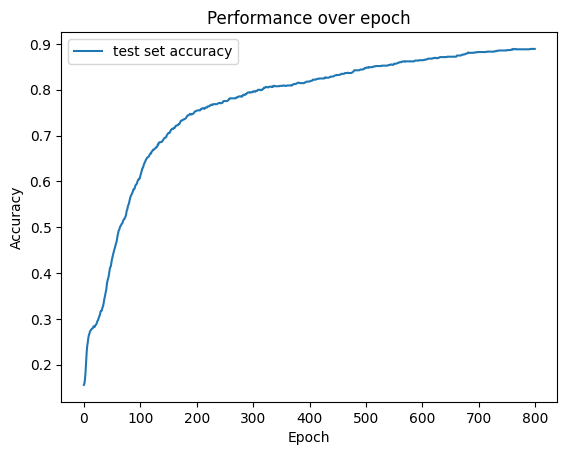

In [14]:
hidden_size = 20
optimal_net = Network([10, hidden_size, 7], 3)

test_accs = []

for _ in range(800):
    train(optimal_net, train_x, train_y, Loss, 0.1, 0.8)
    _, test_acc = evaluate(optimal_net, test_x, test_y, Loss)
    
    test_accs.append(test_acc)

print(test_accs)
# accuracy
plt.figure()
plt.plot(test_accs, label = 'test set accuracy')
plt.legend()
plt.title("Performance over epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

#### Question 14

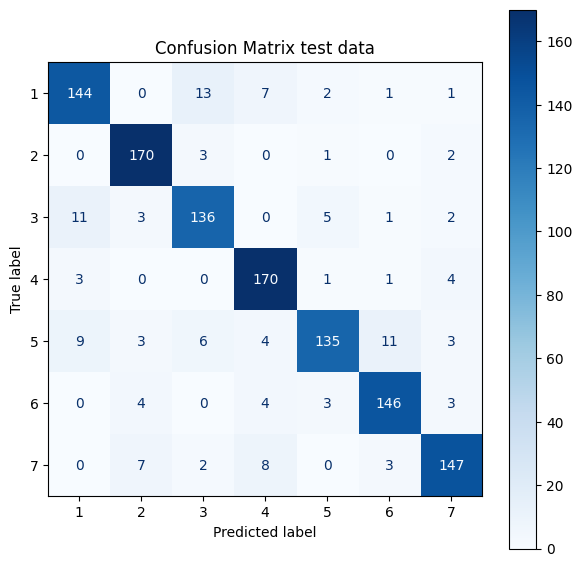

In [45]:
# def confusionMatrix(net, inputs, labels):
#     preds = net.forward(inputs)
#     classes = np.argmax(preds, axis=1) + 1
#     matrix = np.zeros((7, 7), dtype=int)

#     for true, pred in zip(labels.astype(int), classes):
#         matrix[true - 1, pred - 1] += 1
    
#     return matrix

# fig, ax = plt.subplots()
# matrix = confusionMatrix(optimal_net, test_x, test_y)
# ax.matshow(matrix, cmap=plt.cm.Blues)

# for i in range(1, 8):
#     for j in range(1, 8):
#         c = matrix[j - 1, i - 1]
#         ax.text(i - 1, j - 1, str(c), va = 'center', ha = 'center')

preds = np.argmax(optimal_net.forward(test_x), axis=1) + 1
figure = plt.figure(figsize=(7,7))
ax = figure.add_subplot()
disp = met.ConfusionMatrixDisplay.from_predictions(
    test_y,
    preds,
    display_labels=np.unique(targets.astype(int)),
    cmap=plt.cm.Blues,
    ax=ax
)
disp.ax_.set_title("Confusion Matrix test data")
plt.show()


The rows show the true class of the sample from 1-7 and the columns show the predicted class. The diagonal shows correctly classified samples while values off the diagonal show how many were incorrectly classified and how. Since the values on the diagonal are much larger than those off the diagonal, we can see that the system performs very well. As there is an even spread of misclassifications, we can attribute them to noise and not a systemic issue.

#### Question 15

In [83]:
preds = optimal_net.forward(unknown) 
pred_classes = np.argmax(preds, axis=1) + 1
np.savetxt("01_classes.txt", pred_classes, fmt='%d', delimiter=",", newline=",")
with open("01_classes.txt", "w") as f:
    f.write(",".join(map(str, pred_classes)))

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer 20re._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer 20re._

</div>

#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer 20re._

</div>

### 1.7 Reflection

#### Question 18

When machine learning techniques are used to approve bank loans, a misclassification resulting from bias could be potentially damaging due to a potential discrimination lawsuit. THis may be as the system may learn to classify people who can pay back the loan as ones who cant as it has learnt to bias against certain sensitive features. Even if the system is not provided with sensitive features, they may be inferred from other features provided to it.

#### Question 19

An appeal system could be set into place for all who do not agree with the system's classification. This will prompt a human review which will help correct the classification if needed. Affected groups should also be closesly worked with when designing the system in order to better incorporate them into the data set as well as work with them to find a fair threshold. This will help reduce discrimnation by the system. We can obviously never be sure the problem is fixerd as bias will always be present in any dataset and backup system.

### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer 20re. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer 20re. You can also choose to simply include a photo of your solution._

</div>

### 1.9 Division of work

#### Question 22

<div>


|          Component          |  Junhan   |  Jack   |  Madhav  |  Ben  |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     50%     |     50%     |     0%     |     0%     |
| Code (implementation)       |     40%     |     60%     |     0%     |     0%     |
| Code (validation)           |     50%     |     50%     |     0%     |     0%     |
| Experiments (execution)     |     100%     |     0%     |     0%     |     0%     |
| Experiments (analysis)      |     190%     |     0%     |     0%     |     0%     |
| Experiments (visualization) |     190%     |     0%     |     0%     |     0%     |
| Report (original draft)     |     60%     |     40%     |     0%     |     0%     |
| Report (reviewing, editing) |     0%     |     0%     |     50%     |     50%     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite t20m below.**

</div>